# **Import Library**

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Praktikum_DM/Praktikum 11/yahoo_stock.csv')
df.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1825 non-null   object 
 1   High       1825 non-null   float64
 2   Low        1825 non-null   float64
 3   Open       1825 non-null   float64
 4   Close      1825 non-null   float64
 5   Volume     1825 non-null   float64
 6   Adj Close  1825 non-null   float64
dtypes: float64(6), object(1)
memory usage: 99.9+ KB


In [ ]:
df.isnull().sum()

,0
Date,0
High,0
Low,0
Open,0
Close,0
Volume,0
Adj Close,0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# **Preparation**

In [ ]:
# Jika Date masih kolom biasa
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    df = df.set_index('Date')

# Index berbentuk datetime
df.index = pd.to_datetime(df.index)

# Urutkan index
df = df.sort_index()

# Set frequency business day untuk data saham
df = df.asfreq('B')

# Isi missing value karena weekend/libur bursa
df['Close'] = df['Close'].ffill()

series = df['Close']

print(series.head())
print(series.index.freq)

Date
2015-11-23    2086.590088
2015-11-24    2089.139893
2015-11-25    2088.870117
2015-11-26    2088.870117
2015-11-27    2090.110107
Freq: B, Name: Close, dtype: float64
<BusinessDay>


# **Train Test Split**

In [ ]:
# 80% train
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

print("Train 80%:", len(train))
print("Test 20%:", len(test))

Train 80%: 1044
Test 20%: 261


# **Define Best Parameter**

In [ ]:
# Mencari Parameter terbaik (p,d,q)

auto_model = auto_arima(
    train,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=9250.889, Time=2.37 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9259.377, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9261.000, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9260.941, Time=0.34 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9259.745, Time=0.08 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=9257.941, Time=0.74 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=9257.947, Time=0.58 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=9252.169, Time=2.82 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=9252.059, Time=5.63 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=9260.611, Time=0.81 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=9259.234, Time=0.64 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=9258.806, Time=0.54 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=9254.483, Time=3.15 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=9251.497, Time=0.96 sec

Best model:  ARIMA(2,1,2)(0,0,0)

In [ ]:
# Model Terbaik
order = auto_model.order

print("Best ARIMA Order: ", order)

model = ARIMA(train, order=order)
model_fit = model.fit()

print(model_fit.summary())

Best ARIMA Order:  (2, 1, 2)
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1044
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -4620.749
Date:                Mon, 25 May 2026   AIC                           9251.497
Time:                        02:43:08   BIC                           9276.247
Sample:                    11-23-2015   HQIC                          9260.885
                         - 11-21-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3300      0.061     -5.447      0.000      -0.449      -0.211
ar.L2         -0.8753      0.058    -15.054      0.000      -0.989      -0.761
ma.L1          0.2945  

# **Prediksi**

In [ ]:
predictions = model_fit.forecast(steps=len(test))

predictions.index = test.index

print(predictions.head())

Date
2019-11-22    3104.002174
2019-11-25    3103.387989
2019-11-26    3103.186202
2019-11-27    3103.790376
2019-11-28    3103.767593
Freq: B, Name: predicted_mean, dtype: float64


# **Evaluasi**

In [ ]:
rmse = np.sqrt(mean_squared_error(test, predictions))

mape = mean_absolute_percentage_error(test, predictions) * 100

mean_price = series.mean()
rmse_percent = rmse / mean_price * 100

print("Mean:", mean_price)
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

Mean: 2648.3494085436123
RMSE: 280.10
MAPE: 7.47%


# **Train Ulang Dengan Full Data**

In [ ]:
final_model = ARIMA(series, order=order)
final_model_fit = final_model.fit()

# **Prediksi 30 Hari Ke Depan**

In [ ]:
forecast_30 = final_model_fit.forecast(steps=30)

print(forecast_30)

2020-11-23    3559.861496
2020-11-24    3560.026915
2020-11-25    3559.645258
2020-11-26    3559.638608
2020-11-27    3559.700281
2020-11-30    3559.698129
2020-12-01    3559.688331
2020-12-02    3559.689189
2020-12-03    3559.690718
2020-12-04    3559.690501
2020-12-07    3559.690266
2020-12-08    3559.690313
2020-12-09    3559.690349
2020-12-10    3559.690339
2020-12-11    3559.690334
2020-12-14    3559.690336
2020-12-15    3559.690337
2020-12-16    3559.690336
2020-12-17    3559.690336
2020-12-18    3559.690336
2020-12-21    3559.690336
2020-12-22    3559.690336
2020-12-23    3559.690336
2020-12-24    3559.690336
2020-12-25    3559.690336
2020-12-28    3559.690336
2020-12-29    3559.690336
2020-12-30    3559.690336
2020-12-31    3559.690336
2021-01-01    3559.690336
Freq: B, Name: predicted_mean, dtype: float64


# **Membuat Tanggal Prediksi**

In [ ]:
future_dates = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='B'
)

forecast_df =pd.DataFrame({
    'Date': future_dates,
    'Forecast_Close': forecast_30.values
})

forecast_df

,Date,Forecast_Close
0,2020-11-23,3559.861496
1,2020-11-24,3560.026915
2,2020-11-25,3559.645258
3,2020-11-26,3559.638608
4,2020-11-27,3559.700281
5,2020-11-30,3559.698129
6,2020-12-01,3559.688331
7,2020-12-02,3559.689189
8,2020-12-03,3559.690718
9,2020-12-04,3559.690501


# **Visualisasi Prediksi 30 Hari**

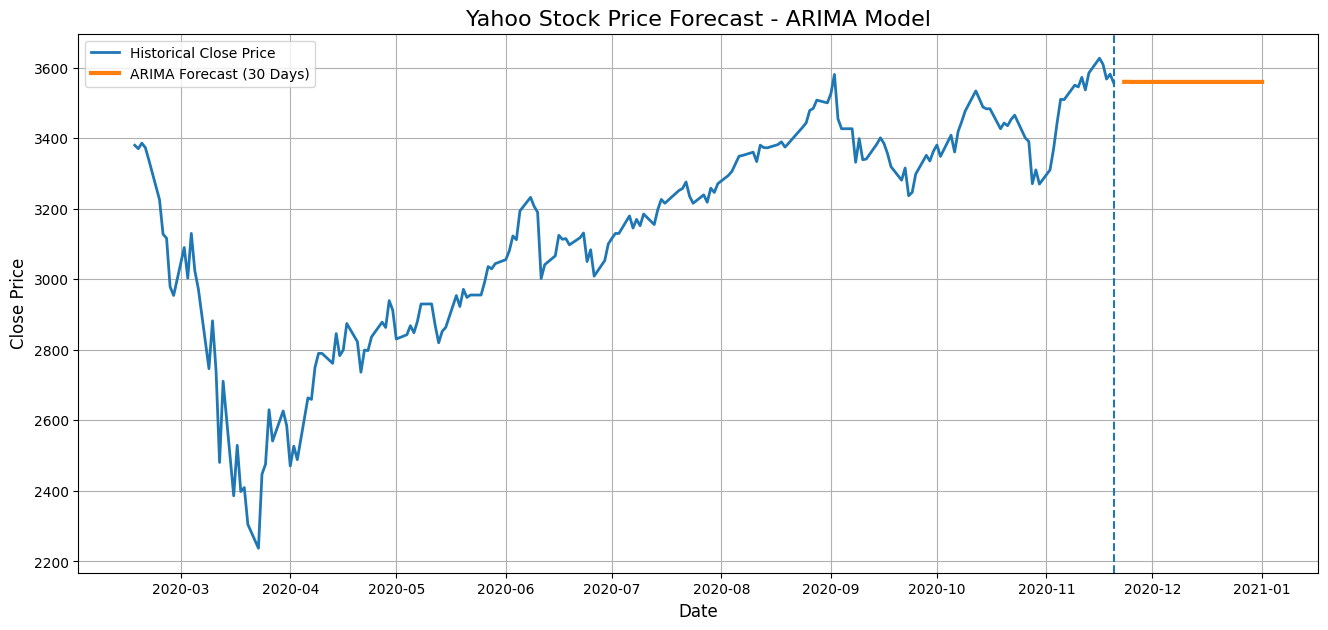

In [ ]:
plt.figure(figsize=(16,7))

# data historis 200 hari terakhir
plt.plot(
    series.index[-200:],
    series[-200:],
    label='Historical Close Price',
    linewidth=2
)

# forecast 30 hari
plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast_Close'],
    label='ARIMA Forecast (30 Days)',
    linewidth=3
)

# titik awal forecast
plt.axvline(
    x=series.index[-1],
    linestyle='--'
)

plt.title('Yahoo Stock Price Forecast - ARIMA Model', fontsize=16)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)

plt.legend()

plt.grid(True)

plt.show()

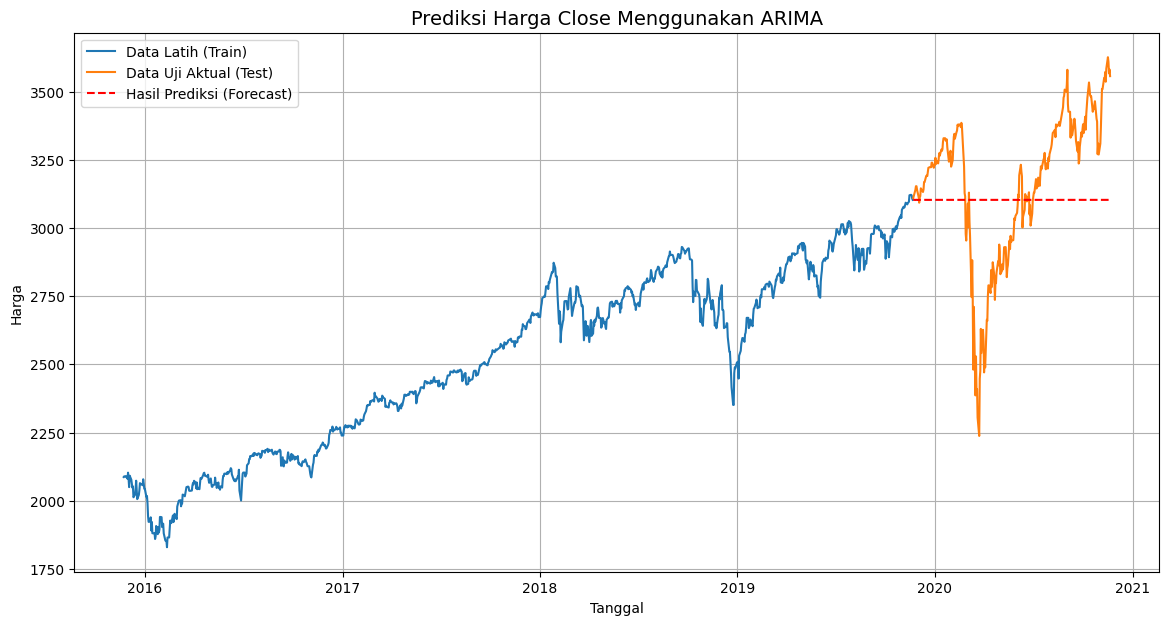

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(train, label='Data Latih (Train)')
plt.plot(test, label='Data Uji Aktual (Test)')
plt.plot(predictions, label='Hasil Prediksi (Forecast)', color='red', linestyle='--')
plt.title('Prediksi Harga Close Menggunakan ARIMA', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.show()